<a href="https://colab.research.google.com/github/m28851119-cmd/Deep-Clustering/blob/main/%E6%B7%B1%E5%BA%A6%E8%81%9A%E7%B1%BB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 导包


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm

#  1. 环境与数据准备

In [10]:
# ==========================================
# 1. 环境与全量数据准备 (50,000张)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")

# 方案三增强转换：加入随机翻转和裁剪
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 方案一、二及评估用的标准转换
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 加载全量训练集
full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=eval_transform)
aug_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

dataloader_plain = DataLoader(full_dataset, batch_size=256, shuffle=False, num_workers=2)
dataloader_aug = DataLoader(aug_dataset, batch_size=256, shuffle=True, num_workers=2)

def cluster_eval(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size): w[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(row_ind, col_ind)]) / y_pred.size

# 提取 50,000 张全量数据
print("提取全量数据特征中...")
X_raw_list, Y_true_list = [], []
for imgs, labels in dataloader_plain:
    X_raw_list.append(imgs.view(imgs.size(0), -1).numpy())
    Y_true_list.append(labels.numpy())
X_raw = np.concatenate(X_raw_list)
Y_true = np.concatenate(Y_true_list)


当前运行设备: cuda
提取全量数据特征中...


# 2. 方案一 & 方案二（传统方法）

In [11]:
print("\n[方案一] 运行 K-means (原始像素)...")
km = KMeans(n_clusters=10, n_init=10, random_state=42)
y_pred1 = km.fit_predict(X_raw)
acc1 = cluster_eval(Y_true, y_pred1)

print("[方案二] 运行 PCA + K-means (50维)...")
X_pca = PCA(n_components=50).fit_transform(X_raw)
y_pred2 = km.fit_predict(X_pca)
acc2 = cluster_eval(Y_true, y_pred2)


[方案一] 运行 K-means (原始像素)...
[方案二] 运行 PCA + K-means (50维)...


# 3. 方案三：完整卷积 DEC

In [13]:
class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Flatten(), nn.Linear(256 * 4 * 4, 512)
        )
        self.decoder = nn.Sequential(
            nn.Linear(512, 256 * 4 * 4), nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 3, stride=2, padding=1, output_padding=1), nn.Tanh()
        )
    def forward(self, x): return self.encoder(x), self.decoder(self.encoder(x))

class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters=10, latent_dim=512):
        super(ClusteringLayer, self).__init__()
        self.centers = nn.Parameter(torch.zeros(n_clusters, latent_dim))
        nn.init.xavier_uniform_(self.centers)
    def forward(self, z):
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.centers)**2, dim=2))
        return q / q.sum(dim=1, keepdim=True)

def get_target_p(q):
    p = q**2 / q.sum(dim=0)
    return p / p.sum(dim=1, keepdim=True)

# A. 预训练阶段 (添加进度条)
print("\n[方案三] 步骤 A: 正在全量数据预训练 (100 Epochs)...")
model = ConvAE().to(device)
opt_ae = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    model.train()
    total_loss = 0
    # 用 tqdm 包装 dataloader，desc 显示当前轮次
    pbar = tqdm(dataloader_aug, desc=f"AE Epoch {epoch+1}/100", unit="batch", leave=False)
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        _, recon = model(imgs)
        loss = F.mse_loss(recon, imgs)

        opt_ae.zero_grad()
        loss.backward()
        opt_ae.step()

        total_loss += loss.item()
        # 进度条右侧实时更新 MSE Loss
        pbar.set_postfix(mse_loss=f"{loss.item():.4f}")

    # 每 10 轮在屏幕上打印一次汇总
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100] 平均重构误差: {total_loss/len(dataloader_aug):.6f}")

# B. 初始化特征提取 (添加进度条)
print("\n步骤 B: 提取全量特征并初始化聚类中心...")
model.eval()
all_z = []
with torch.no_grad():
    for imgs, _ in tqdm(dataloader_plain, desc="Extracting Features"):
        z = model.encoder(imgs.to(device))
        all_z.append(z.cpu().numpy())
all_z = np.concatenate(all_z)
km_init = KMeans(n_clusters=10, n_init=20).fit(all_z)

# C. 深度联合优化 (添加进度条)
print("\n步骤 C: 深度联合优化 (100 Epochs)...")
cl_layer = ClusteringLayer().to(device)
cl_layer.centers.data.copy_(torch.tensor(km_init.cluster_centers_))
opt_dec = optim.SGD(list(model.encoder.parameters()) + list(cl_layer.parameters()), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(opt_dec, step_size=30, gamma=0.5)

for epoch in range(100):
    model.encoder.train()
    total_kl_loss = 0
    pbar = tqdm(dataloader_aug, desc=f"DEC Epoch {epoch+1}/100", unit="batch", leave=False)
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        z = model.encoder(imgs)
        q = cl_layer(z)
        p = get_target_p(q).detach()

        loss = F.kl_div(q.log(), p, reduction='batchmean')
        opt_dec.zero_grad()
        loss.backward()
        opt_dec.step()

        total_kl_loss += loss.item()
        pbar.set_postfix(kl_loss=f"{loss.item():.6f}")

    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100] KL 散度: {total_kl_loss/len(dataloader_aug):.6f}")

# D. 最终评估 (添加进度条)
print("\n步骤 D: 获取最终预测结果...")
model.eval()
final_z = []
with torch.no_grad():
    for imgs, _ in tqdm(dataloader_plain, desc="Final Predicting"):
        z = model.encoder(imgs.to(device))
        final_z.append(z.cpu().numpy())
final_z = np.concatenate(final_z)
y_pred3 = cl_layer(torch.tensor(final_z).to(device)).argmax(dim=1).cpu().numpy()
acc3 = cluster_eval(Y_true, y_pred3)


[方案三] 步骤 A: 正在全量数据预训练 (100 Epochs)...


Epoch [10/100] 平均重构误差: 0.542498


Epoch [20/100] 平均重构误差: 0.528466


Epoch [30/100] 平均重构误差: 0.521485


Epoch [40/100] 平均重构误差: 0.517866


...

Epoch [70/100] KL 散度: 0.146797


Epoch [80/100] KL 散度: 0.146639


Epoch [90/100] KL 散度: 0.147371


Epoch [100/100] KL 散度: 0.146631

步骤 D: 获取最终预测结果...


Final Predicting: 100%|██████████| 196/196 [00:11<00:00, 17.34it/s]


# 可视化


生成可视化图表中...


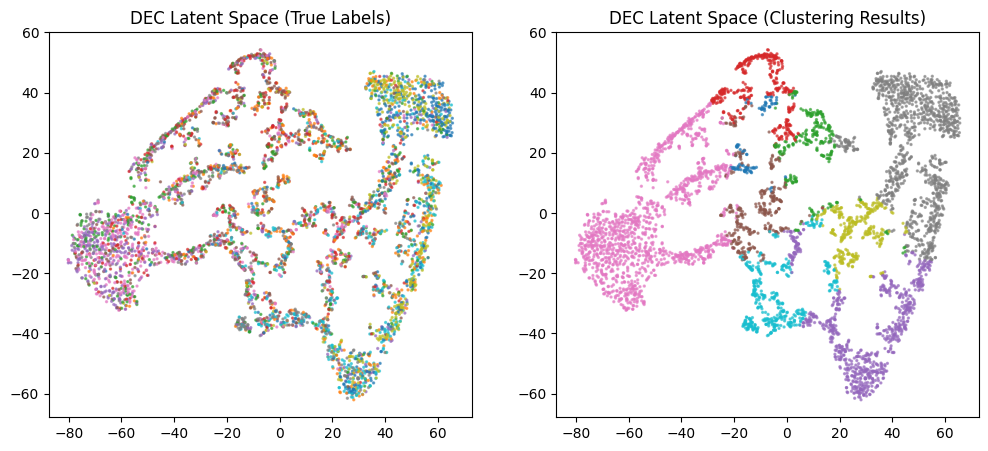

In [14]:
# 可视化对比
print("\n生成可视化图表中...")
tsne = TSNE(n_components=2, random_state=42)
z_vis = tsne.fit_transform(final_z[:5000])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(z_vis[:, 0], z_vis[:, 1], c=Y_true[:5000], cmap='tab10', s=2, alpha=0.6)
plt.title("DEC Latent Space (True Labels)")
plt.subplot(1, 2, 2)
plt.scatter(z_vis[:, 0], z_vis[:, 1], c=y_pred3[:5000], cmap='tab10', s=2, alpha=0.6)
plt.title("DEC Latent Space (Clustering Results)")
plt.show()


# 对比

In [15]:
print("\n" + "="*35)
print(f"方案一 K-means:     ACC={acc1:.4f}")
print(f"方案二 PCA+K-means: ACC={acc2:.4f}")
print(f"方案三 卷积 DEC:    ACC={acc3:.4f}")
print("="*35)


方案一 K-means:     ACC=0.2063
方案二 PCA+K-means: ACC=0.2065
方案三 卷积 DEC:    ACC=0.2298
